In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/aptos2019/valid.csv
/kaggle/input/aptos2019/test.csv
/kaggle/input/aptos2019/train_1.csv
/kaggle/input/aptos2019/val_images/val_images/17f6c7072f61.png
/kaggle/input/aptos2019/val_images/val_images/0243404e8a00.png
/kaggle/input/aptos2019/val_images/val_images/0083ee8054ee.png
/kaggle/input/aptos2019/val_images/val_images/0ac436400db4.png
/kaggle/input/aptos2019/val_images/val_images/0d0a21fd354f.png
/kaggle/input/aptos2019/val_images/val_images/02da652c74b8.png
/kaggle/input/aptos2019/val_images/val_images/15e96e848b46.png
/kaggle/input/aptos2019/val_images/val_images/059bc89df7f4.png
/kaggle/input/aptos2019/val_images/val_images/04d029cfb612.png
/kaggle/input/aptos2019/val_images/val_images/08752092140d.png
/kaggle/input/aptos2019/val_images/val_images/0ef4c61dc056.png
/kaggle/input/aptos2019/val_images/val_images/1a7e3356b39c.png
/kaggle/input/aptos2019/val_images/val_images/06be1092a062.png
/kaggle/input/aptos2019/val_images/val_images/03a7f4a5786f.png
/kaggle/input/a

In [7]:

"""final training, with the augmented dataset"""
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from transformers import DetrModel, DetrConfig
import pandas as pd
import numpy as np
from PIL import Image
import cv2
from tqdm import tqdm

torch.manual_seed(42)

BATCH_SIZE = 8
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_CLASSES = 5
IMG_SIZE = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 2

print(f"Using device: {DEVICE}")

DATASET_DIR = "/kaggle/input"
TRAIN_CSV = os.path.join(DATASET_DIR, "aptos2019/train_1.csv")
TRAIN_IMG_DIR = os.path.join(DATASET_DIR, "aptos2019/train_images/train_images")
AUGMENTED_IMG_DIR = os.path.join(DATASET_DIR, "augmented-dataset/augmented_images/augmented_images")
UPDATED_CSV = os.path.join(DATASET_DIR, "augmented-dataset/updated_train.csv")
MODEL_SAVE_PATH = "/kaggle/working/detr_mobilenet_model.pth"

class MobileNetDETRClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V1")
        self.features = mobilenet.features

        for param in self.features.parameters():
            param.requires_grad = False

        self.feature_processor = nn.Sequential(
            nn.Conv2d(1280, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((8, 8)),
            nn.Conv2d(512, 3, kernel_size=1)
        )
        detr_config = DetrConfig.from_pretrained("facebook/detr-resnet-50")
        detr_config.num_labels = num_classes
        self.detr = DetrModel.from_pretrained("facebook/detr-resnet-50", config=detr_config)

        self.classification_head = nn.Sequential(
            nn.Linear(detr_config.d_model, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.features(x)

        features_processed = self.feature_processor(features)
        detr_outputs = self.detr(pixel_values=features_processed)
        pooled_output = detr_outputs.last_hidden_state.mean(dim=1)

        return self.classification_head(pooled_output)


class APTOSDataset(Dataset):
    def __init__(self, csv_file, train_img_dir, augmented_img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.train_img_dir = train_img_dir
        self.augmented_img_dir = augmented_img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.iloc[idx]['id_code']
        label = self.data.iloc[idx]['diagnosis']
        is_augmented = self.data.iloc[idx]['is_augmented']

        # Use the is_augmented column from CSV (it's reliable!)
        if is_augmented:
            # Try both .npy and .png for augmented images
            npy_path = os.path.join(self.augmented_img_dir, f"{img_id}.npy")
            png_path = os.path.join(self.augmented_img_dir, f"{img_id}.png")

            if os.path.exists(npy_path):
                try:
                    img_array = np.load(npy_path)
                    # Handle array format
                    if len(img_array.shape) == 3 and img_array.shape[0] == 3:
                        img_array = np.transpose(img_array, (1, 2, 0))
                    if img_array.dtype == np.float32 and img_array.max() <= 1.0:
                        img_array = (img_array * 255).astype(np.uint8)
                    image = Image.fromarray(img_array.astype(np.uint8))
                except Exception as e:
                    print(f"Error loading npy {img_id}: {e}")
                    image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
            elif os.path.exists(png_path):
                try:
                    image = Image.open(png_path).convert('RGB')
                except Exception as e:
                    print(f"Error loading png {img_id}: {e}")
                    image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
            else:
                print(f"Warning: Augmented image {img_id} not found (.npy or .png)")
                image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        else:
            # Load original image from train directory
            img_path = os.path.join(self.train_img_dir, f"{img_id}.png")
            if os.path.exists(img_path):
                try:
                    image = Image.open(img_path).convert('RGB')
                except Exception as e:
                    print(f"Error loading train image {img_id}: {e}")
                    image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
            else:
                print(f"Warning: Train image {img_id}.png not found")
                image = torch.zeros((3, IMG_SIZE, IMG_SIZE))

        # Apply transforms
        if self.transform and not isinstance(image, torch.Tensor):
            image = self.transform(image)

        return image, label



transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


dataset = APTOSDataset(
    csv_file=UPDATED_CSV,
    train_img_dir=TRAIN_IMG_DIR,
    augmented_img_dir=AUGMENTED_IMG_DIR,
    transform=transform
)


print(f"Dataset size: {len(dataset)}")


train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"Train set: {len(train_dataset)} samples")
print(f"Validation set: {len(val_dataset)} samples")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)


model = MobileNetDETRClassifier(num_classes=NUM_CLASSES)
model = model.to(DEVICE)


criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    [
        {'params': model.classification_head.parameters()},
        {'params': model.feature_processor.parameters()},
        {'params': model.detr.parameters(), 'lr': LEARNING_RATE * 0.1}
    ],
    lr=LEARNING_RATE
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training")
    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix(
            loss=running_loss/len(progress_bar),
            acc=100.*correct/total
        )

    return running_loss / len(loader), correct / total

from sklearn.metrics import cohen_kappa_score

def quadratic_weighted_kappa(y_true, y_pred):
    """
    Compute Quadratic Weighted Kappa (QWK).
    y_true: list or numpy array of ground truth labels
    y_pred: list or numpy array of predicted labels
    """
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation")
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # store for QWK
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            progress_bar.set_postfix(
                loss=running_loss/len(progress_bar),
                acc=100.*correct/total
            )

    val_loss = running_loss / len(loader)
    val_acc = correct / total
    val_qwk = quadratic_weighted_kappa(all_labels, all_preds)

    return val_loss, val_acc, val_qwk


history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_qwk': []
}

best_val_qwk = -1.0  # QWK can be negative if worse than chance

print(f"Starting training on {DEVICE}...")
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_qwk = validate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_qwk'].append(val_qwk)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val QWK: {val_qwk:.4f}")

    # ✅ Save best model based on QWK
    if val_qwk > best_val_qwk:
        best_val_qwk = val_qwk
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'val_qwk': val_qwk
        }, MODEL_SAVE_PATH)
        print(f"✅ Model saved (best QWK={val_qwk:.4f}) to {MODEL_SAVE_PATH}")

print("Training completed!")

Using device: cuda
Dataset size: 7500
Train set: 6000 samples
Validation set: 1500 samples


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

Starting training on cuda...

Epoch 1/20


Validation: 100%|██████████| 188/188 [00:54<00:00,  3.44it/s, acc=50.4, loss=1.1]  


Train Loss: 1.2921, Train Acc: 0.3912
Val Loss: 1.0956, Val Acc: 0.5040, Val QWK: 0.5808
✅ Model saved (best QWK=0.5808) to /kaggle/working/detr_mobilenet_model.pth

Epoch 2/20


...

Train Loss: 0.5410, Train Acc: 0.7908
Val Loss: 0.8290, Val Acc: 0.7047, Val QWK: 0.7995
✅ Model saved (best QWK=0.7995) to /kaggle/working/detr_mobilenet_model.pth

Epoch 19/20


Validation: 100%|██████████| 188/188 [00:52<00:00,  3.58it/s, acc=69.3, loss=0.843]


Train Loss: 0.5505, Train Acc: 0.7835
Val Loss: 0.8429, Val Acc: 0.6927, Val QWK: 0.7893

Epoch 20/20


Validation: 100%|██████████| 188/188 [00:52<00:00,  3.55it/s, acc=70.3, loss=0.835]


Train Loss: 0.5401, Train Acc: 0.7888
Val Loss: 0.8349, Val Acc: 0.7033, Val QWK: 0.7932
Training completed!


Evaluating: 100%|██████████| 46/46 [00:29<00:00,  1.54it/s]


Test Accuracy: 0.8060
Test QWK: 0.8500
Test Weighted F1-score: 0.7918

Classification Report:
              precision    recall  f1-score   support

           0     0.9752    0.9899    0.9825       199
           1     0.4848    0.5333    0.5079        30
           2     0.6481    0.8046    0.7179        87
           3     0.3333    0.1765    0.2308        17
           4     0.6429    0.2727    0.3830        33

    accuracy                         0.8060       366
   macro avg     0.6169    0.5554    0.5644       366
weighted avg     0.7975    0.8060    0.7918       366



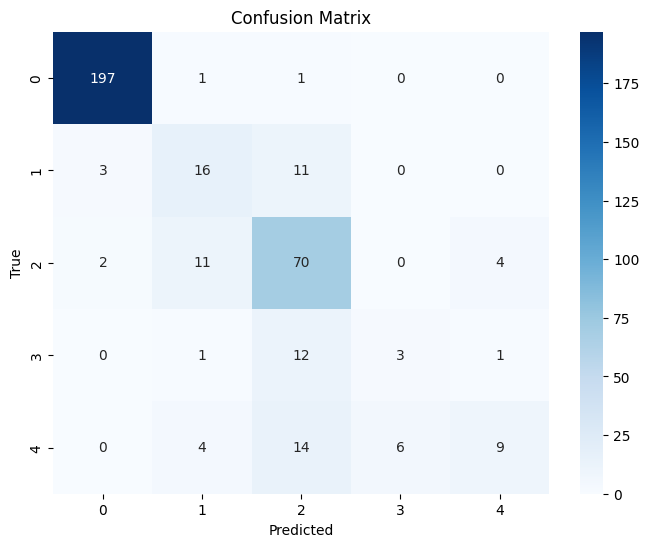

In [ ]:
"""Evaluating trained model on test dataset and generating classification report and confusion matrix"""
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

class APTOSTestDataset(Dataset):
    def __init__(self, csv_file, test_img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.test_img_dir = test_img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.iloc[idx]['id_code']
        label = self.data.iloc[idx]['diagnosis']

        img_path = os.path.join(self.test_img_dir, f"{img_id}.png")
        if os.path.exists(img_path):
            try:
                image = Image.open(img_path).convert('RGB')
            except:
                print(f"Error loading image {img_id}")
                image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        else:
            print(f"Warning: Test image {img_id}.png not found")
            image = torch.zeros((3, IMG_SIZE, IMG_SIZE))

        if self.transform and not isinstance(image, torch.Tensor):
            image = self.transform(image)

        return image, label

TEST_CSV = os.path.join(DATASET_DIR, "aptos2019/test.csv")   # replace with your test CSV
TEST_IMG_DIR = os.path.join(DATASET_DIR, "aptos2019/test_images/test_images")  # folder with test images

test_dataset = APTOSTestDataset(
    csv_file=TEST_CSV,
    test_img_dir=TEST_IMG_DIR,
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute metrics
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test QWK: {qwk:.4f}")
    print(f"Test Weighted F1-score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, digits=4))

    # Plot confusion matrix
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
# Load best saved model
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)


# Evaluate
evaluate_model(model, test_loader, DEVICE)


In [ ]:
"""Loading Model and Predicting on a Single Image"""
import torch
import torch.nn as nn
from torchvision import models
from transformers import DetrModel, DetrConfig

NUM_CLASSES = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MobileNetDETRClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V1")
        self.features = mobilenet.features

        # Freeze MobileNet features
        for param in self.features.parameters():
            param.requires_grad = False

        # Feature processor to feed DETR
        self.feature_processor = nn.Sequential(
            nn.Conv2d(1280, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((8, 8)),
            nn.Conv2d(512, 3, kernel_size=1)
        )

        # DETR backbone
        detr_config = DetrConfig.from_pretrained("facebook/detr-resnet-50")
        detr_config.num_labels = num_classes
        self.detr = DetrModel.from_pretrained("facebook/detr-resnet-50", config=detr_config)

        # Classification head
        self.classification_head = nn.Sequential(
            nn.Linear(detr_config.d_model, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.features(x)
        features_processed = self.feature_processor(features)
        detr_outputs = self.detr(pixel_values=features_processed)
        pooled_output = detr_outputs.last_hidden_state.mean(dim=1)
        return self.classification_head(pooled_output)
MODEL_SAVE_PATH = "/kaggle/input/augmented/detr_mobilenet_model.pth"

# Rebuild the model
model = MobileNetDETRClassifier(num_classes=NUM_CLASSES)
model = model.to(DEVICE)
model.eval()

# Load the checkpoint safely
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Model loaded. Trained for {checkpoint['epoch']+1} epochs, val QWK={checkpoint['val_qwk']:.4f}")

from torchvision import transforms
from PIL import Image

IMG_SIZE = 512
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def predict(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(image_tensor)
        pred_class = torch.argmax(output, dim=1).item()
    return pred_class

# Example usage
image_path = "/kaggle/input/aptos2019/test_images/test_images/e4e343eaae2a.png"
pred_class = predict(image_path)
print("Predicted class:", pred_class)


✅ Model loaded. Trained for 18 epochs, val QWK=0.7995
Predicted class: 2


Image: f2f569a64949.png | True: 0 | Predicted: 0
Image: e6f0ce5bf282.png | True: 2 | Predicted: 2
Image: e5de79795c1d.png | True: 0 | Predicted: 0
Image: fbfa925506f6.png | True: 0 | Predicted: 0
Image: e8ddfc9709ce.png | True: 0 | Predicted: 0


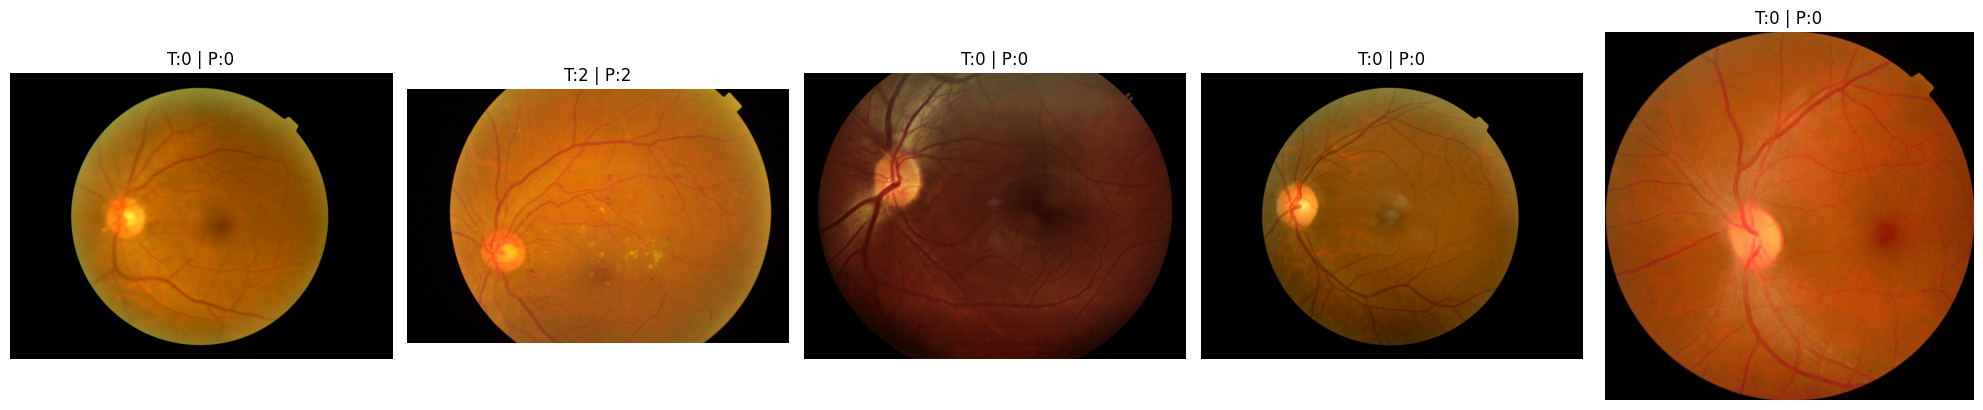

In [ ]:
"""Evaluating model on random test images and comparing predictions with true labels"""
import pandas as pd
import os, random
import matplotlib.pyplot as plt

# Path to CSV and test images
test_csv = "/kaggle/input/aptos2019/test.csv"  # replace with actual name
test_images_dir = "/kaggle/input/aptos2019/test_images/test_images"

# Load test labels
test_df = pd.read_csv(test_csv)  # must have columns: id_code, diagnosis

# Randomly sample 5 images
sampled_rows = test_df.sample(5, random_state=42)

results = []
for _, row in sampled_rows.iterrows():
    img_path = os.path.join(test_images_dir, f"{row['id_code']}.png")
    true_class = row['diagnosis']
    pred_class = predict(img_path)   # your existing function
    
    results.append((row['id_code'], true_class, pred_class))
    print(f"Image: {row['id_code']}.png | True: {true_class} | Predicted: {pred_class}")

# --- Optional visualization ---
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (img_id, true_cls, pred_cls) in enumerate(results):
    img_path = os.path.join(test_images_dir, f"{img_id}.png")
    image = Image.open(img_path).convert("RGB")
    axes[i].imshow(image)
    axes[i].set_title(f"T:{true_cls} | P:{pred_cls}", fontsize=12)
    axes[i].axis("off")
plt.tight_layout()
plt.show()
